<center> <img src="https://sic.cultura.gob.mx/images/64988" alt="Texto descriptivo" style="display: block; margin-left: auto; margin-right: auto;">
<center> Materia: Inteligencia Artificial </center>
<center> Alumnos: Luis Roberto Rocha Barrón  <center>
<center>  Profesor: Roberto Landeta Rojas </center>
<center> Fecha de entrega: 12/05/2026  </center>
  Proyecto final: Redes Neuronales(Deep Learning)



# PRONÓSTICOS SOBRE SERIES DE TIEMPO CON REDES NEURONALES EN DARTS


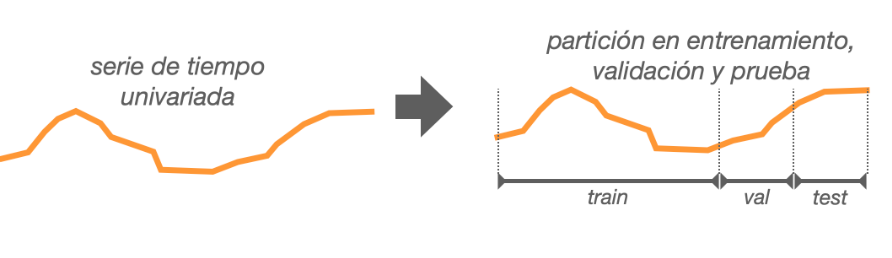

Preparar los datos

Usaremos un set de datos que contiene el registro histórico de niveles de generación de energía eléctrica en un país entre enero de 2019 y marzo de 2025.

In [ ]:
!pip install darts[torch]

Y ahora leamos el set de datos como una Serie de Tiempo en Pandas:


In [ ]:
import pandas as pd

# Cargar dataset como serie de tiempo en Pandas
df = pd.read_csv('energia.csv', parse_dates=['fecha_hora'])
df.set_index('fecha_hora', inplace=True)
df

,hidro
fecha_hora,
2019-01-01 00:00:00,1383.0
2019-01-01 01:00:00,1112.0
2019-01-01 02:00:00,1030.0
2019-01-01 03:00:00,972.0
2019-01-01 04:00:00,960.0
...,...
2025-03-19 19:00:00,1922.0
2025-03-19 20:00:00,1920.0
2025-03-19 21:00:00,1881.0


Para poder usar los modelos de Darts es necesario convertir la serie de tiempo en Pandas a una serie de tiempo en Darts:

In [ ]:
from darts import TimeSeries

serie = TimeSeries.from_dataframe(df, time_col=None, value_cols='hidro')

Veamos la frecuencia y la duración de esta serie:

In [ ]:
print(serie.freq)
print(serie.duration)

<Hour>
2269 days 23:00:00


Y verifiquemos si existen datos faltantes:

In [ ]:
serie.gaps()

,gap_start,gap_end


Graficamos la serie

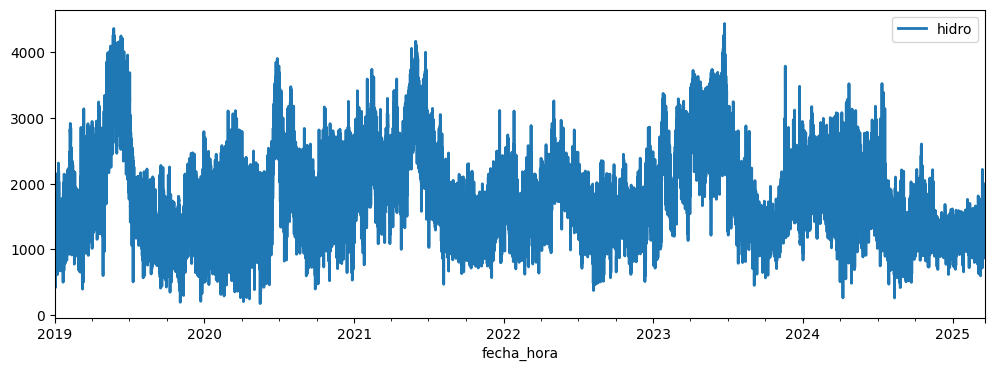

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
serie.plot(ax=ax);

Ahora podemos usar algunas funciones de Darts para realizar la partición en entrenamiento, validación y prueba.

Al final la idea es entrenar diferentes tipos de modelos, basados en Redes Neuronales, capaces de predecir 24 horas a futuro.

Así que realizaremos la partición del set de datos de la siguiente forma:

- Entrenamiento y validación: la totalidad de la serie exceptuando las últimas 24 horas (90% entrenamiento, 10% validación)
- Prueba: las últimas 24 horas de la serie de tiempo

Veamos cómo hacer esta partición:

In [ ]:
N = len(serie) # Número total de time-stamps
Nfut = 24 # Número de horas a predecir a futuro

# Partición
train_val = serie[:-Nfut] # Todos los datos exceptuando las últimas 24 horas
train, val = train_val.split_before(0.9) # 90% entrenamiento, 10% validación
test = serie[-Nfut:] # Las últimas 24 horas

# Verificación de los tamaños
print(train.shape)
print(val.shape)
print(test.shape)

(49009, 1, 1)
(5447, 1, 1)
(24, 1, 1)


A continuación debemos escalar los datos, pues idealmente deberían estar en el rango de -1 a 1 (o 0 a 1).

Para ello usaremos "MinMaxScaler" de Scikit-learn junto con "Scaler" de Darts. Es importante tener en cuenta que el set de datos de entrenamiento se usará como referencia para escalar los datos de validación y prueba:

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from darts.dataprocessing.transformers import Scaler

# Crear instancias de MinMaxScaler y de Scaler
scaler = MinMaxScaler(feature_range=(-1, 1))
transformer = Scaler(scaler)

# Escalar set de entrenamiento con "fit_transform" y set de
# validación con "transform"
tr_s = transformer.fit_transform(train)
vl_s = transformer.transform(val)

# Verificar rangos de valores originales y resultantes:
print('Rangos de valores originales (train, val):')
print(train.all_values().min(), train.all_values().max())
print(val.all_values().min(), val.all_values().max())
print('\nRangos de valores escalados (tr_s, vl_s):')
print(tr_s.all_values().min(), tr_s.all_values().max())
print(vl_s.all_values().min(), vl_s.all_values().max())

Rangos de valores originales (train, val):
175.0 4434.0
261.0 2603.0

Rangos de valores escalados (tr_s, vl_s):
-0.9999999999999999 1.0
-0.9596149330828833 0.1401737497065041


Pronósticos con "RNNModel"
Este es el tipo de modelo más simple en Darts y permite implementar Redes Neuronales Recurrentes (RNN, LSTM o GRU) de manera sencilla.

Es importante tener en cuenta que este tipo de modelo genera predicciones uni-step (un instante de tiempo a futuro).

In [ ]:
# Modelo LSTM
from darts.models import RNNModel

# Crear instancia del modelo + generación de dataset supervisado
modelo_lstm = RNNModel(
    model = "LSTM", # RNN, LSTM, GRU
    input_chunk_length = 50, # Número de time-steps de entrada
    # output_chunk_length = 24, # Número de time-steps de salida (a predecir)
    training_length = 74, # Tamaño total de un dato de entrenamiento

    # Ejemplos de hiper-parámetros
    hidden_dim = 256, # Tamaño estado oculto
    dropout = 0, # Dropout
    batch_size = 64, # Tamaño lote
    n_epochs = 5, # Número de iteraciones de entrenamiento
    optimizer_kwargs = {"lr": 1e-2}, # Hiperparámetros del optimizador
    model_name = "LSTM_50_1", # Nombre del modelo
)

# Entrenar el modelo
modelo_lstm.fit(
    tr_s,
    val_series=vl_s,
    verbose=True,
)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 265 K  | train
6 | V               | Linear           | 257    | train
-------------------------------------------------------------
265 K     Trainable params
0         Non-trainable p

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


RNNModel(model=LSTM, hidden_dim=256, n_rnn_layers=1, dropout=0, training_length=74, input_chunk_length=50, batch_size=64, n_epochs=5, optimizer_kwargs={'lr': 0.01}, model_name=LSTM_50_1)

Verifiquemos dos cosas en este modelo: el número de time-steps de salida y el nombre del modelo:

In [ ]:
print(modelo_lstm.output_chunk_length)
print(modelo_lstm.model_name)

1
LSTM_50_1


Y ahora podemos generar predicciones usando el modelo entrenado. Como el esquema de generación de predicciones es el mismo, independientemente del modelo, implementaremos una sencilla función que podremos reutilizar una y otra vez:

In [ ]:
from darts.metrics import rmse, mape

def generar_pronosticos(modelo, n, serie_entrada, serie_prueba, transformer):
    # Introducir la serie de entrada ESCALADA generar "n" predicciones escaladas
    preds_s = modelo.predict(n=n, series=serie_entrada)

    # Escalamiento inverso de las predicciones
    preds = transformer.inverse_transform(preds_s)

    # Calcular métricas de desempeño
    error_rmse = rmse(serie_prueba, preds)
    error_mape = mape(serie_prueba, preds)

    # Mostrar serie original + predicción + métricas de desempeño
    fig, ax = plt.subplots(figsize=(10, 6))
    serie_prueba.plot(label="Generación real", ax=ax)
    preds.plot(label="Pronóstico", ax=ax)
    plt.title(f"{modelo.model_name} - RMSE: {error_rmse:.2f}, MAPE: {error_mape:.2f}%")
    plt.legend();

Y usemos esta función para ver cómo se comporta el pronóstico generado por este modelo:

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

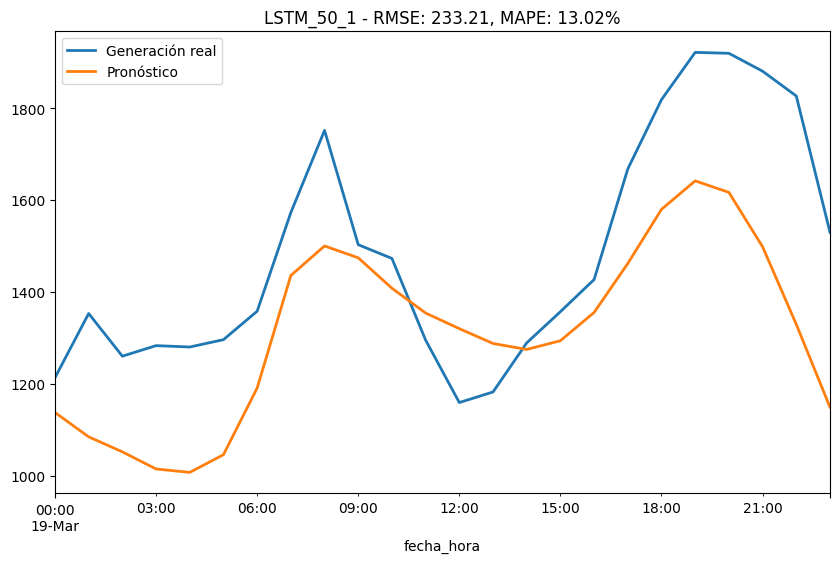

In [ ]:
generar_pronosticos(modelo_lstm, 24, vl_s, test, transformer)